# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Nguyen Van A"  # TODO: Họ và tên
STUDENT_ID = "2152xxx"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")


Student: Nguyen Van A (2152xxx)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\Vinh\Desktop\mliot-pyml-2026-hw\week02\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# N1
shifted_logits = logits - logits.max(axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / exp_logits.sum(axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)


In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# N2
train_feature_mean = X_train.mean(axis=0)
train_feature_std = X_train.std(axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std


In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# N3
correct_mask = predicted_classes == true_labels
high_confidence_mask = confidence_scores >= confidence_threshold
review_mask = (~correct_mask) | (~high_confidence_mask)
review_indices = np.where(review_mask)[0]

print("correct_mask:", correct_mask)
print("high_confidence_mask:", high_confidence_mask)
print("review_indices:", review_indices)


correct_mask: [ True False  True False]
high_confidence_mask: [False False  True False]
review_indices: [0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = normalized_batch[:, :, ::-1, :].copy()
augmented_batch[0, 0, 0, 0] = 1.0

print(normalized_batch.dtype, normalized_batch.shape)
print("independent memory:", augmented_batch.base is None or augmented_batch.base is not normalized_batch)


float32 (2, 4, 4, 3)
independent memory: True


# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

1. Mỗi dòng đại diện cho một mẫu xe (một model/phiên bản xe cụ thể) trong bộ dữ liệu 1985 Auto Imports.
2. Ký hiệu missing value trong CSV là dấu `?`.
3. `symboling` là mức đánh giá rủi ro bảo hiểm do actuary gán cho xe, giá trị từ -3 (rủi ro thấp/an toàn) đến +3 (rủi ro cao); xe được xếp hạng rủi ro cao hơn mức bảo hiểm ước tính ban đầu sẽ tăng dần symboling.


## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == "?").sum().sum()

print("raw_shape:", raw_shape)
print("raw_missing_marker_count:", raw_missing_marker_count)
raw_df.dtypes


raw_shape: (205, 26)
raw_missing_marker_count: 59


symboling              int64
normalized_losses        str
make                     str
fuel_type                str
aspiration               str
num_doors                str
body_style               str
drive_wheels             str
engine_location          str
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type              str
num_cylinders            str
engine_size            int64
fuel_system              str
bore                     str
stroke                   str
compression_ratio    float64
horsepower               str
peak_rpm                 str
city_mpg               int64
highway_mpg            int64
price                    str
dtype: object

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# D2
df_clean = raw_df.replace("?", np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")
missing_by_column = df_clean.isna().sum()

missing_by_column[missing_by_column > 0]


normalized_losses    41
num_doors             2
bore                  4
stroke                4
horsepower            2
peak_rpm              2
price                 4
dtype: int64

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

Không nên fill tất cả các cột numeric bằng cùng một giá trị (ví dụ 0 hoặc mean chung) vì mỗi cột có đơn vị và phân phối rất khác nhau (giá xe tính bằng USD hàng chục nghìn, trong khi bore/stroke chỉ vài inch) — dùng một giá trị chung sẽ tạo ra outlier giả hoặc bóp méo thống kê của cột đó. Với `price`, vì đây gần như là biến mục tiêu chính của bài EDA (dùng để phân tích quan hệ với các feature khác), nên drop các dòng thiếu price sẽ an toàn hơn fill, vì giá trị điền vào (mean/median) có thể làm sai lệch các phân tích tương quan và trực quan hóa liên quan tới giá. `normalized_losses` thiếu tới 41/205 dòng (~20%), là cột thiếu nhiều nhất; nếu fill bằng mean/median sẽ làm giảm variance thực của biến và có thể che giấu pattern thật, còn nếu drop sẽ mất khá nhiều dữ liệu — cách hợp lý cho bài EDA này là loại `normalized_losses` khỏi các phân tích chính thay vì cố gắng impute.


## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# D3
analysis_df = df_clean.dropna(subset=AUTO_FEATURES)
X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype=np.float64)
auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

print("analysis_df shape:", analysis_df.shape)
print("auto_feature_mean:", auto_feature_mean)
print("auto_feature_std:", auto_feature_std)


analysis_df shape: (199, 26)
auto_feature_mean: [ 2556.03015075   126.8241206    103.39698492    25.20100503
    30.68341709 13243.4321608 ]
auto_feature_std: [5.18547730e+02 4.16478926e+01 3.74593675e+01 6.43559503e+00
 6.83217899e+00 7.95863536e+03]


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# D4
price_index = AUTO_FEATURES.index("price")
price_values = X_auto[:, price_index]
price_z = (price_values - price_values.mean()) / price_values.std()
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df.loc[price_outlier_mask]

print("Số lượng outlier:", price_outlier_mask.sum())
price_outliers[["make", "price"]]


Số lượng outlier: 14


,make,price
15,bmw,30760.0
16,bmw,41315.0
17,bmw,36880.0
47,jaguar,32250.0
48,jaguar,35550.0
49,jaguar,36000.0
70,mercedes-benz,31600.0
71,mercedes-benz,34184.0
72,mercedes-benz,35056.0
73,mercedes-benz,40960.0


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# D5
engine_price_corr = np.corrcoef(analysis_df["engine_size"], analysis_df["price"])[0, 1]
price_by_body_style = analysis_df.groupby("body_style")["price"].mean().sort_index()

print("engine_price_corr:", engine_price_corr)
price_by_body_style


engine_price_corr: 0.8738869517981515


body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9958.373134
sedan          14459.755319
wagon          12500.166667
Name: price, dtype: float64

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

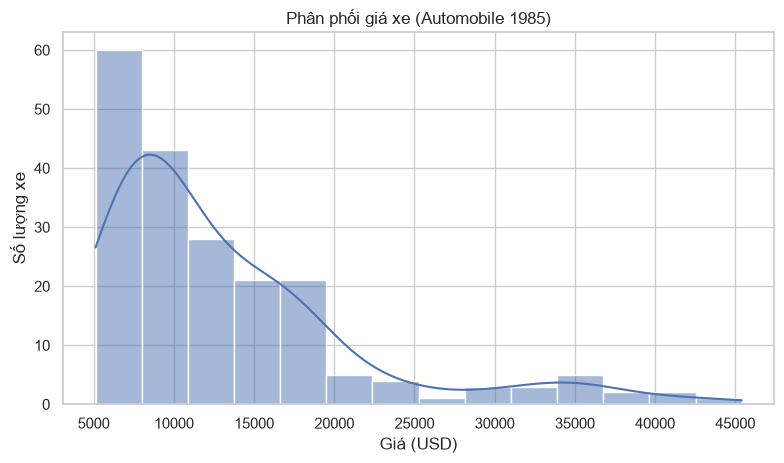

In [20]:
# M2.1: histogram/KDE của price
fig, ax = plt.subplots()
sns.histplot(analysis_df["price"], kde=True, ax=ax, color="#4C72B0")
ax.set_title("Phân phối giá xe (Automobile 1985)")
ax.set_xlabel("Giá (USD)")
ax.set_ylabel("Số lượng xe")
plt.tight_layout()
plt.show()


**Nhận xét:** Phân phối giá lệch phải rõ rệt: phần lớn xe có giá trong khoảng 5,000–17,000 USD (trung vị ~10,345 USD), trong khi một nhóm nhỏ xe hạng sang (BMW, Jaguar, Mercedes-Benz, Porsche) kéo dài đuôi phân phối lên tới hơn 40,000 USD.


## M2.2 Dataset có cân bằng theo body style không?

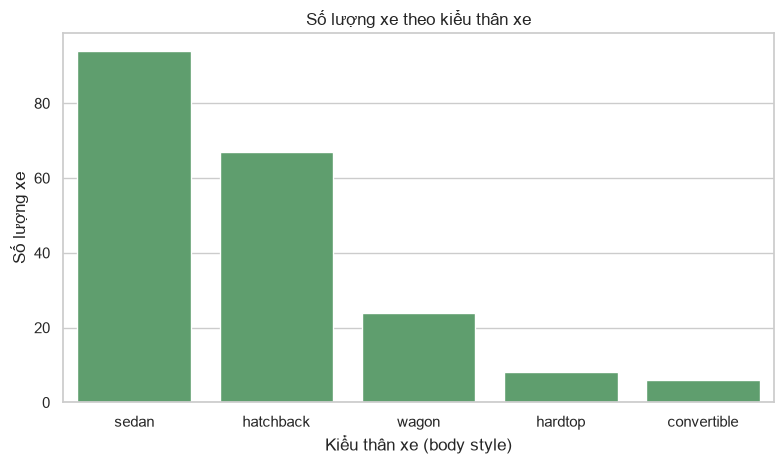

In [21]:
# M2.2: countplot của body_style
fig, ax = plt.subplots()
order = analysis_df["body_style"].value_counts().index
sns.countplot(data=analysis_df, x="body_style", order=order, ax=ax, color="#55A868")
ax.set_title("Số lượng xe theo kiểu thân xe")
ax.set_xlabel("Kiểu thân xe (body style)")
ax.set_ylabel("Số lượng xe")
plt.tight_layout()
plt.show()


**Nhận xét:** Dataset không cân bằng theo body style: `sedan` (94 xe) và `hatchback` (67 xe) chiếm phần lớn, trong khi `convertible` chỉ có 6 xe và `hardtop` có 8 xe — cần lưu ý khi so sánh giữa các nhóm vì kích thước mẫu chênh lệch lớn.


## M2.3 Price khác nhau theo body style ra sao?

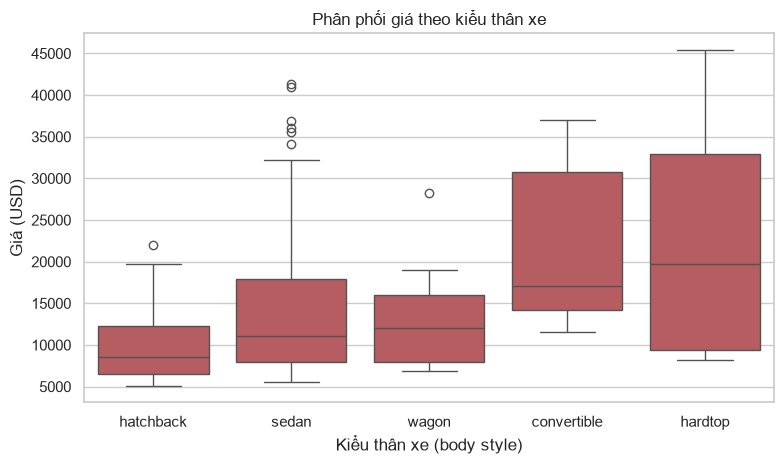

In [22]:
# M2.3: boxplot price theo body_style
fig, ax = plt.subplots()
order = analysis_df.groupby("body_style")["price"].median().sort_values().index
sns.boxplot(data=analysis_df, x="body_style", y="price", order=order, ax=ax, color="#C44E52")
ax.set_title("Phân phối giá theo kiểu thân xe")
ax.set_xlabel("Kiểu thân xe (body style)")
ax.set_ylabel("Giá (USD)")
plt.tight_layout()
plt.show()


**Nhận xét:** `hardtop` và `convertible` có giá trung vị cao nhất và phân tán rộng nhất, trong khi `hatchback` có giá thấp nhất và tương đối tập trung; đây cũng là hai nhóm có ít mẫu nhất nên khoảng tin cậy của trung vị kém ổn định hơn các nhóm còn lại.


## M2.4 Engine size liên quan thế nào tới price?

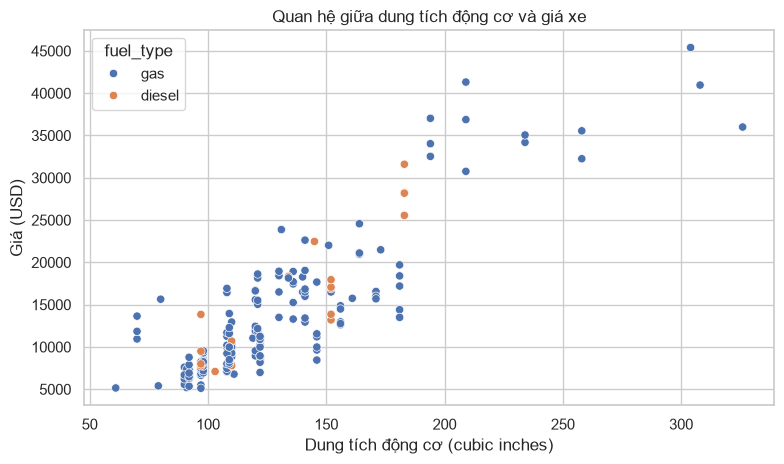

In [23]:
# M2.4: scatterplot engine_size và price, hue=fuel_type
fig, ax = plt.subplots()
sns.scatterplot(data=analysis_df, x="engine_size", y="price", hue="fuel_type", ax=ax)
ax.set_title("Quan hệ giữa dung tích động cơ và giá xe")
ax.set_xlabel("Dung tích động cơ (cubic inches)")
ax.set_ylabel("Giá (USD)")
plt.tight_layout()
plt.show()


**Nhận xét:** Có quan hệ đồng biến khá mạnh giữa dung tích động cơ và giá (hệ số tương quan Pearson ≈ 0.87); xe chạy diesel có xu hướng nằm ở vùng dung tích động cơ trung bình nhưng giá không hề thấp hơn xe chạy gas tương ứng.


## M2.5 Các feature numeric tương quan ra sao?

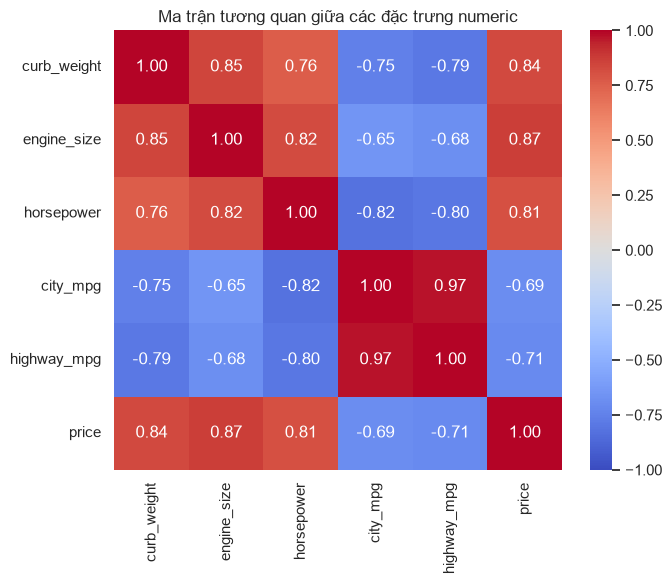

In [24]:
# M2.5: correlation heatmap
corr_matrix = analysis_df[AUTO_FEATURES].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1)
ax.set_title("Ma trận tương quan giữa các đặc trưng numeric")
plt.tight_layout()
plt.show()


**Nhận xét:** `city_mpg` và `highway_mpg` tương quan gần như tuyệt đối với nhau (~0.97) và đều tương quan âm mạnh với `curb_weight`, `engine_size`, `horsepower`, `price`; nói cách khác xe càng nặng, động cơ càng lớn/mạnh và càng đắt thì càng tốn nhiên liệu hơn.


## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

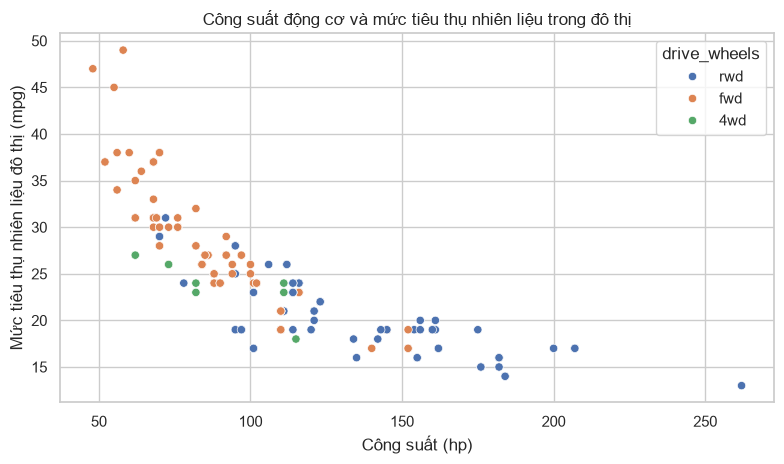

In [25]:
# M2.6: biểu đồ tự chọn — công suất động cơ vs mức tiêu thụ nhiên liệu đô thị, theo hệ dẫn động
fig, ax = plt.subplots()
sns.scatterplot(data=analysis_df, x="horsepower", y="city_mpg", hue="drive_wheels", ax=ax)
ax.set_title("Công suất động cơ và mức tiêu thụ nhiên liệu trong đô thị")
ax.set_xlabel("Công suất (hp)")
ax.set_ylabel("Mức tiêu thụ nhiên liệu đô thị (mpg)")
plt.tight_layout()
plt.show()


**Nhận xét:** Công suất càng cao thì `city_mpg` càng giảm rõ rệt; xe dẫn động cầu trước (fwd) tập trung ở vùng công suất thấp–trung bình và mpg cao, trong khi xe dẫn động cầu sau (rwd) trải rộng hơn về phía công suất cao và mpg thấp.


# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

Dữ liệu Automobile 1985 gồm 205 xe với 26 thuộc tính; sau khi loại dòng thiếu ít nhất một trong sáu feature phân tích chính (`curb_weight`, `engine_size`, `horsepower`, `city_mpg`, `highway_mpg`, `price`), còn lại 199 dòng. Một số phát hiện chính: (1) giá xe lệch phải mạnh, phần lớn dưới 17,000 USD nhưng có đuôi dài tới hơn 45,000 USD từ các hãng hạng sang như BMW, Jaguar, Mercedes-Benz, Porsche; (2) dung tích động cơ tương quan dương khá mạnh với giá (r ≈ 0.87); (3) `city_mpg` và `highway_mpg` tương quan gần như tuyệt đối (r ≈ 0.97) và cả hai tương quan âm mạnh với trọng lượng, dung tích động cơ và giá; (4) dataset mất cân bằng theo `body_style`, sedan/hatchback chiếm đa số trong khi convertible/hardtop rất ít mẫu; (5) dùng ngưỡng |z| > 2, phát hiện 14 xe có giá là outlier, đều thuộc các hãng hạng sang.

Hai hạn chế của dataset: kích thước mẫu nhỏ (199 xe) và phân bố lệch giữa các hãng/kiểu thân xe khiến các thống kê theo nhóm nhỏ (convertible, hardtop) kém tin cậy; ngoài ra `normalized_losses` thiếu tới ~20% dữ liệu nên khó dùng cho phân tích sâu.

Một ví dụ correlation không đồng nghĩa causation: `city_mpg` và `price` tương quan âm, nhưng không phải giá cao "gây ra" mpg thấp — cả hai đều bị chi phối bởi biến ẩn là kích thước/công suất động cơ.

Câu hỏi nên phân tích tiếp: liệu `make` (thương hiệu) có phải là yếu tố dự đoán giá độc lập với kích thước/công suất động cơ, hay gần như toàn bộ chênh lệch giá giữa các hãng có thể giải thích bằng các đặc trưng kỹ thuật đã có?
